# Exact Solver Experiments (Campaign-Time Calibration)

All experiments use campaign-time calibration with η parameter for energy scaling.
Four slope regimes: random, positive, negative, zero.

**Datasets:** C101 (50), R101 (50), RC101 (100), R101 (100), C101 (100).


| Section | Description |
|---------|-------------|
| 1. Scalability | All 5 datasets, random slopes |
| 2. Slope comparison | All 5 datasets × 4 slopes (with gap logs) |
| 3. Gap convergence plot | Plotted from Section 2 data (no re-solve) |
| 4. Eta sweep | All 5 datasets × 5 η |
| 5. Value of loitering | All 5 datasets × 5 η × 2 |
| 6. Speed by η | All 5 datasets × 3 η |
| 7. Arrival time by slope | All 5 datasets × 3 slopes (negative, positive, zero) |
| 8. Single detailed run | R101 (50) |
| 9. Reproducibility | All 5 datasets × 5 seeds |

In [1]:
import sys
import os

# Ensure repo root is on sys.path regardless of kernel cwd
_notebook_dir = os.path.dirname(os.path.abspath("__file__"))
_repo_root = os.path.abspath(os.path.join(_notebook_dir, "..")) if os.path.basename(_notebook_dir) == "experiments" else _notebook_dir
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)
os.chdir(_repo_root)

from uav_routing.environment import Environment
from uav_routing.environment.calibration import calibrate, calibration_info
from uav_routing.environment.graph import Graph
from uav_routing.environment.drone import Drone
from uav_routing.solver.exact import solve_model_gurobi, print_table
from uav_routing.solver.analysis import (
    eta_sensitivity, arrival_time_histogram, speed_histogram,
    speed_histogram_by_eta, scalability_table, value_of_loitering,
    gap_convergence_plot
)
import gurobipy as gp
import pandas as pd

# Dataset paths (relative to repo root)
datasets = {
    "C101 (50)":  "datasets/data/50_c101.txt",
    "R101 (50)":  "datasets/data/50_r101.txt",
    "RC101 (100)": "datasets/data/rc101.txt",
    "R101 (100)": "datasets/data/r101.txt",
    "C101 (100)": "datasets/data/c101.txt",
}

# Common parameters
SEED = 42
TIME_LIMIT = 600
SORTIE_TIME = 3.0

def make_instance(path, slope='random', graph_seed=1, eta=1.0):
    """Create a campaign-calibrated instance."""
    graph = Graph(path=path, slope=slope, seed=graph_seed)
    uav = Drone(base=graph.graph['base'])
    calib = calibrate(
        graph=graph,
        tour_length=len(graph.nodes) // 2,
        drone=uav,
        drone_sortie_time=SORTIE_TIME,
        calibration_method="campaign",
    )
    return Environment(calib, uav, eta=eta), graph, uav

print(f"Working directory: {os.getcwd()}")

Working directory: /Users/kirtisoglu/GitHub/UAV-Routing


## 1. Scalability Table

Solve all datasets with campaign-time calibration (eta=1, random slopes).
Report: nodes, objective, gap, solve time, tour length.

**Settings:** $\eta = 1$, random slopes, campaign-time calibration, $T_\text{sortie} = 3$h, time limit = 600s.

**Purpose:** Establish baseline performance and identify which instances the exact solver can close within the time limit. 50-node instances should solve to optimality; 100-node instances will likely hit the time limit with a nonzero gap.

In [2]:
rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        instance, graph, uav = make_instance(path)
        print(f"\n{'='*60}")
        print(f"Solving {name}...")
        res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                 env=env, prune=False, stats=False)

        energy_util = "-"
        if res and res.get("arc_data"):
            total_energy = sum(
                uav.socp_energy_function(ad['t'], ad['y'], ad['z'])
                for ad in res['arc_data'].values()
            )
            energy_util = f"{total_energy / instance.max_energy * 100:.2f}"

        rows.append({
            "Instance": name,
            "Nodes": len(graph.nodes),
            "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
            "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
            "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
            "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            "Energy util (%)": energy_util,
        })
        if res and res.get("tour"):
            print_table(instance, res)

df_scale = pd.DataFrame(rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_scale


Solving C101 (50)...

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       2208756.15       1376363.54    0.8091             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3098336.63       3101807.07    1.8233            270.87   [270.9, 873.8] -2.136742
    32->42          323.30            36.60        32.89       4468237.01       4472558.40    2.6291            594.17  [594.2, 1301.9] -1.635858
    42->33          166.60             0.00        61.00       4374364.10       4375809.61    2.5722            760.78  [760.2, 1380.6] -0.397723
    33->17          532.42           111.08        33.45       7357154.82       7359972.54    4.3264           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73       3420278.9

,Instance,Nodes,Objective,Gap (%),Time (s),Tour nodes,Energy util (%)
0,C101 (50),51,14669.20,0.00,5.6,33,100.00
1,R101 (50),51,144232.37,0.00,2.7,6,100.00
2,RC101 (100),101,227078.36,82.45,600.3,10,100.00
3,R101 (100),101,293439.33,0.00,51.7,12,100.00
4,C101 (100),101,24385.38,13.72,600.2,37,100.00


## 2. Slope Regime Comparison

Compare random, positive, negative, and zero slopes on all datasets.
- Random: mixed decay/growth (breaks timing symmetry)
- Positive: growth only (all nodes reward late arrival)
- Negative: decay only (all nodes reward early arrival)
- Zero: static info (classical OP — massive solver symmetry)

**Settings:** $\eta = 1$, campaign-time calibration, time limit = 600s.

**Purpose:** Demonstrate the impact of information dynamics on solver difficulty and solution structure. Gap convergence logs are captured here for plotting in Section 3.

In [3]:
from uav_routing.solver.analysis import solve_with_gap_log

slope_rows = []
gap_logs = {}  # Store gap logs for Section 3: key = (dataset_name, slope)

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        for slope in ['random', 'positive', 'negative', 'zero']:
            print(f"\n{'='*60}")
            print(f"Solving {name} | slope={slope}...")
            instance, graph, uav = make_instance(path, slope=slope)

            res, gap_log = solve_with_gap_log(instance, seed=SEED,
                                               time_limit=TIME_LIMIT, env=env)
            gap_logs[(name, slope)] = gap_log

            slope_rows.append({
                "Instance": name,
                "Slope": slope,
                "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
                "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
                "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
                "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            })
            if res and res.get("tour"):
                print_table(instance, res)

df_slopes = pd.DataFrame(slope_rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_slopes


Solving C101 (50) | slope=random...

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       2208756.15       1376363.54    0.8091             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3098336.63       3101807.07    1.8233            270.87   [270.9, 873.8] -2.136742
    32->42          323.30            36.60        32.89       4468237.01       4472558.40    2.6291            594.17  [594.2, 1301.9] -1.635858
    42->33          166.60             0.00        61.00       4374364.10       4375809.61    2.5722            760.78  [760.2, 1380.6] -0.397723
    33->17          532.42           111.08        33.45       7357154.82       7359972.54    4.3264           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73 

,Instance,Slope,Objective,Gap (%),Time (s),Tour nodes
0,C101 (50),random,14669.20,0.00,4.6,33
1,C101 (50),positive,25473.29,2.13,600.0,38
2,C101 (50),negative,483.14,0.00,2.3,23
3,C101 (50),zero,820.00,4.88,600.1,46
4,R101 (50),random,144232.37,0.00,3.1,6
5,R101 (50),positive,211603.09,0.00,14.2,9
6,R101 (50),negative,161.00,0.00,0.6,7
7,R101 (50),zero,208.00,0.00,2.3,10
8,RC101 (100),random,230960.29,77.33,600.1,9
9,RC101 (100),positive,305202.40,133.53,600.1,16


## 3. Gap Convergence Plot (Slope Impact)

MIP gap vs solve time for all slope regimes, plotted from Section 2 gap logs (no re-solve).

**Purpose:** Visualize how slopes and instance geometry interact with solver tractability.
- **Positive slopes** (growth only): single dominant "arrive late" strategy helps pruning → fastest convergence.
- **Negative slopes** (decay only): single dominant "arrive early" strategy → similar pruning benefit.
- **Zero slopes** (static info): classical OP, arrival time irrelevant → symmetry makes B&B harder.
- **Random slopes** (mixed ±γ): complex per-node trade-offs → slowest convergence, largest gap.

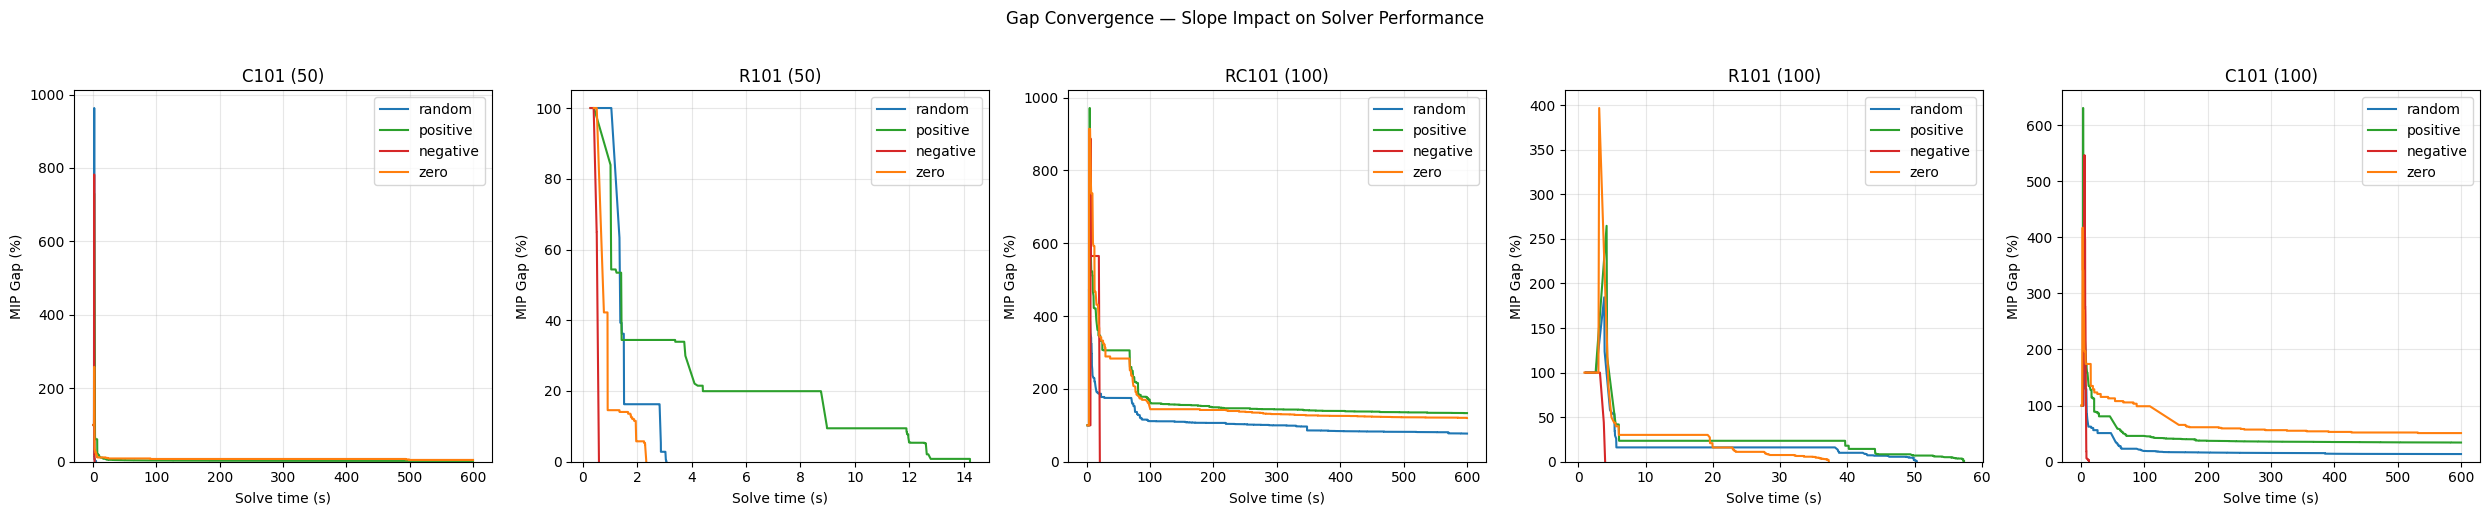

In [4]:
import matplotlib.pyplot as plt

slope_colors = {'random': '#1f77b4', 'positive': '#2ca02c', 'negative': '#d62728', 'zero': '#ff7f0e'}
slopes = ['random', 'positive', 'negative', 'zero']

n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), squeeze=False)
axes = axes[0]

for idx, name in enumerate(datasets.keys()):
    ax = axes[idx]
    for slope in slopes:
        key = (name, slope)
        if key in gap_logs and gap_logs[key]:
            times, gaps = zip(*gap_logs[key])
            ax.plot(times, gaps, label=slope, color=slope_colors[slope], linewidth=1.5)
    ax.set_xlabel('Solve time (s)')
    ax.set_ylabel('MIP Gap (%)')
    ax.set_title(name)
    ax.legend()
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)

fig.suptitle('Gap Convergence — Slope Impact on Solver Performance', y=1.02)
fig.tight_layout()

## 4. Energy Sensitivity (eta sweep)

Sweep eta in {0.6, 0.75, 1.0, 1.25, 1.5} to study the energy-time trade-off across all datasets.

**Settings:** Random slopes, campaign-time calibration, time limit = 600s.

**Purpose:** Study the energy–information trade-off. As $\eta$ decreases:
- Fewer nodes can be visited (shorter tours).
- Energy utilization should approach 100% (the constraint becomes binding).
- The solver should find optimal solutions faster (smaller feasible region).
- The objective should degrade gracefully — a steep drop indicates that the energy constraint is highly restrictive.

In [5]:
eta_values = (0.5, 0.75, 1.0, 1.25, 1.50)
eta_rows = []

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        for eta in eta_values:
            instance, _, _ = make_instance(path, eta=eta)
            print(f"\n{'='*60}")
            print(f"{name} | eta={eta}")
            res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False)
            eta_rows.append({
                "Instance": name,
                "eta": eta,
                "Objective": round(res["obj"], 2) if res and res.get("obj") else None,
                "Gap (%)": f"{res['gap']*100:.2f}" if res and res.get("gap") is not None else "-",
                "Time (s)": round(res["solve_time"], 1) if res and res.get("solve_time") else "-",
                "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            })
            if res and res.get("tour"):
                print_table(instance, res)

df_eta = pd.DataFrame(eta_rows)
print(f"\n{'='*60}")
print("SUMMARY")
df_eta


C101 (50) | eta=0.5

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       1368035.99       1376363.54    1.6181             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3101146.37       3101807.07    3.6466            270.87   [270.9, 873.8] -2.136742
    32->24          297.09            90.88        33.85       4100297.31       4106679.35    4.8280            567.96  [568.0, 1258.3] -0.626915
    24->33          192.23             0.00        39.72       2776557.48       2779873.91    3.2682            760.19  [760.2, 1380.6] -0.397723
    33->17          533.01           114.93        33.71       7363655.50       7367578.34    8.6617           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0.00        50.73       3423345.66

,Instance,eta,Objective,Gap (%),Time (s),Tour nodes
0,C101 (50),0.50,9505.56,28.96,600.0,18
1,C101 (50),0.75,13928.62,2.36,600.1,24
2,C101 (50),1.00,14669.20,0.00,4.2,33
3,C101 (50),1.25,14669.20,0.00,3.9,33
4,C101 (50),1.50,14669.20,0.00,4.7,33
5,R101 (50),0.50,52064.22,0.01,61.5,3
6,R101 (50),0.75,91339.87,0.00,61.9,5
7,R101 (50),1.00,144232.37,0.00,2.5,6
8,R101 (50),1.25,144625.34,0.00,12.6,7
9,R101 (50),1.50,144625.34,0.00,10.2,7


## 5. Value of Loitering

Compare full model (L >= d, loitering allowed) vs no-loiter model (L = d).
Quantifies objective gain from speed flexibility across eta values and all datasets.

**Settings:** All datasets, random slopes, campaign-time calibration, time limit = 600s.

**Purpose:** Quantify the value of variable-speed flight (loitering). The full model allows $L_{ij} \geq d_{ij}$ (the drone can fly slower than optimal to adjust arrival timing). The no-loiter model forces $L_{ij} = d_{ij}$. Expected:
- At tight $\eta$, loitering gain is small (energy is the bottleneck, not timing).
- At loose $\eta$, loitering gain is significant (the drone uses excess energy to optimize arrival times).

In [6]:
eta_values = (0.5, 0.75, 1.0, 1.25, 1.50)
loiter_rows = []

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        for eta in eta_values:
            instance, _, _ = make_instance(path, eta=eta)

            print(f"\n{'='*60}")
            print(f"{name} | eta={eta} | FULL MODEL (loitering allowed)")
            res_full = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                          env=env, prune=False, stats=False, no_loiter=False)
            if res_full and res_full.get("tour"):
                print_table(instance, res_full)

            print(f"\n{'-'*60}")
            print(f"{name} | eta={eta} | NO-LOITER (L = d)")
            res_nol = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                                         env=env, prune=False, stats=False, no_loiter=True)
            if res_nol and res_nol.get("tour"):
                print_table(instance, res_nol)

            obj_full = res_full["obj"] if res_full and res_full.get("obj") else None
            obj_nol = res_nol["obj"] if res_nol and res_nol.get("obj") else None
            gain = None
            if obj_full and obj_nol and obj_nol > 0:
                gain = f"{(obj_full - obj_nol) / obj_nol * 100:.2f}"

            loiter_rows.append({
                "Instance": name,
                "eta": eta,
                "Obj (full)": round(obj_full, 2) if obj_full else None,
                "Obj (no-loiter)": round(obj_nol, 2) if obj_nol else None,
                "Gain (%)": gain,
                "Tour nodes (full)": len(res_full["tour"]) - 2 if res_full and res_full.get("tour") else 0,
                "Tour nodes (no-loiter)": len(res_nol["tour"]) - 2 if res_nol and res_nol.get("tour") else 0,
            })

df_loiter = pd.DataFrame(loiter_rows)
print(f"\n{'='*60}")
print("SUMMARY — Value of Loitering")
df_loiter


C101 (50) | eta=0.5 | FULL MODEL (loitering allowed)

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       1368035.99       1376363.54    1.6181             87.38    [87.4, 637.9] -1.316378
    20->32          183.50             0.00        47.18       3101146.37       3101807.07    3.6466            270.87   [270.9, 873.8] -2.136742
    32->24          297.09            90.88        33.85       4100297.31       4106679.35    4.8280            567.96  [568.0, 1258.3] -0.626915
    24->33          192.23             0.00        39.72       2776557.48       2779873.91    3.2682            760.19  [760.2, 1380.6] -0.397723
    33->17          533.01           114.93        33.71       7363655.50       7367578.34    8.6617           1293.20  [865.0, 1293.2]  3.176094
    17->25          183.50             0

,Instance,eta,Obj (full),Obj (no-loiter),Gain (%),Tour nodes (full),Tour nodes (no-loiter)
0,C101 (50),0.50,9505.56,9445.16,0.64,18,18
1,C101 (50),0.75,13928.62,13625.92,2.22,24,27
2,C101 (50),1.00,14669.20,14120.03,3.89,33,31
3,C101 (50),1.25,14669.20,14120.03,3.89,33,31
4,C101 (50),1.50,14669.20,14120.03,3.89,33,31
5,R101 (50),0.50,52064.22,51576.98,0.94,3,3
6,R101 (50),0.75,91339.87,89819.29,1.69,5,5
7,R101 (50),1.00,144232.37,144232.37,-0.00,6,6
8,R101 (50),1.25,144625.34,144625.34,0.00,7,7
9,R101 (50),1.50,144625.34,144625.34,0.00,7,7


## Not: Loiter ile yeterince kazanc gormememizin ve bazen negatif kazanc gormemizin nedeni buyuk olasilikla su: Bir arc icin loiter > 0 ise bu arc uzerinde hep v=33 hizi ile yolculuk yapiyor. v=33 loiter yaparken enerji minimize ediyor ama aktif seyahat ederken minimize etmiyor. Eger loiter suresi, aktif seyahat suresini domine etmiyorsa, "no loiter" testinde UAV ayni arc'i v=44.31 ile gittiginde daha az enerji harcar. Bunu hemen ustteki tablolardan check etmek mumkun.

## Bunu speed icin iki variable tanimlayarak cozebilirdik. Yapamayiz demistiniz. Enerjiyi E = E_loiter + E_travel olarak tanimlasaydik yine SOCP donusumu yapabilirdik. Makalenin en buyuk acigi da bu bence. Discussion kismina future work olarak ekledim.

# 6. Speed Distribution by eta

How does the drone adjust speed when energy is tight vs abundant?

Overlaid histograms showing the distribution of edge speeds $v_{ij}$ for $\eta \in \{0.5, 0.75, 1.0, 1.25, 1.5\}$ on all datasets.

**Purpose:** Reveal how the drone adapts its speed profile under different energy budgets:
- **Tight $\eta$:** Speeds cluster near $v_\text{opt}$ (minimum energy per meter).
- **Loose $\eta$:** Speeds spread across $[v_\text{min}, v_\text{max}]$ — the drone deliberately adjusts speed to optimize arrival timing.
- This figure illustrates the speed–energy–information coupling that distinguishes our model from classical orienteering.

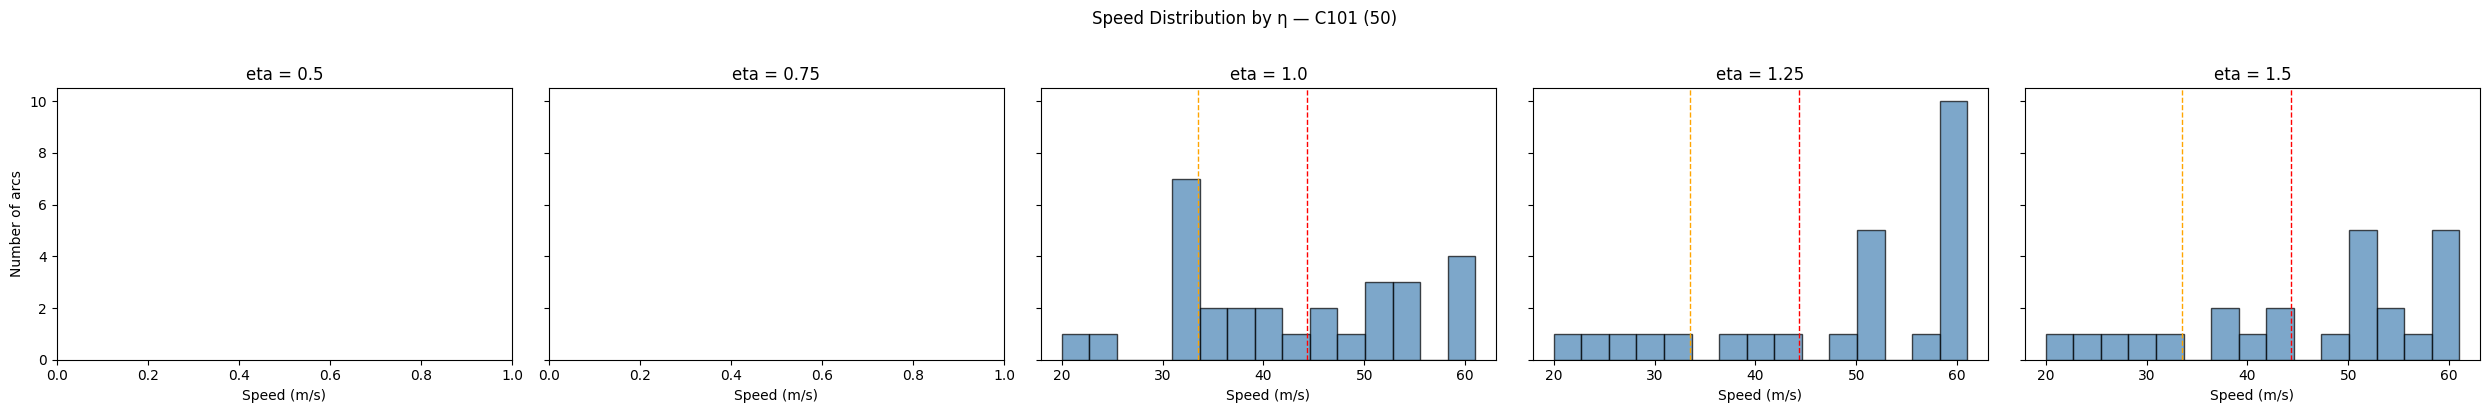

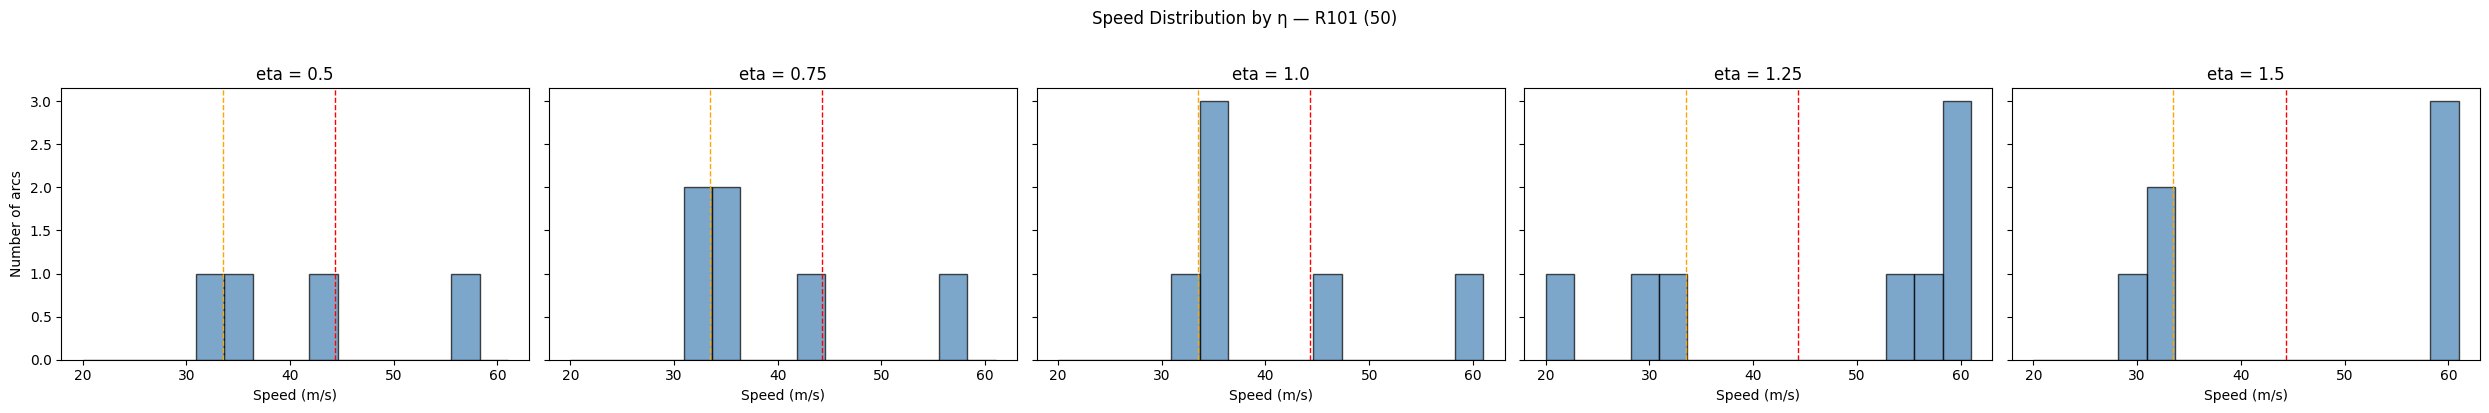

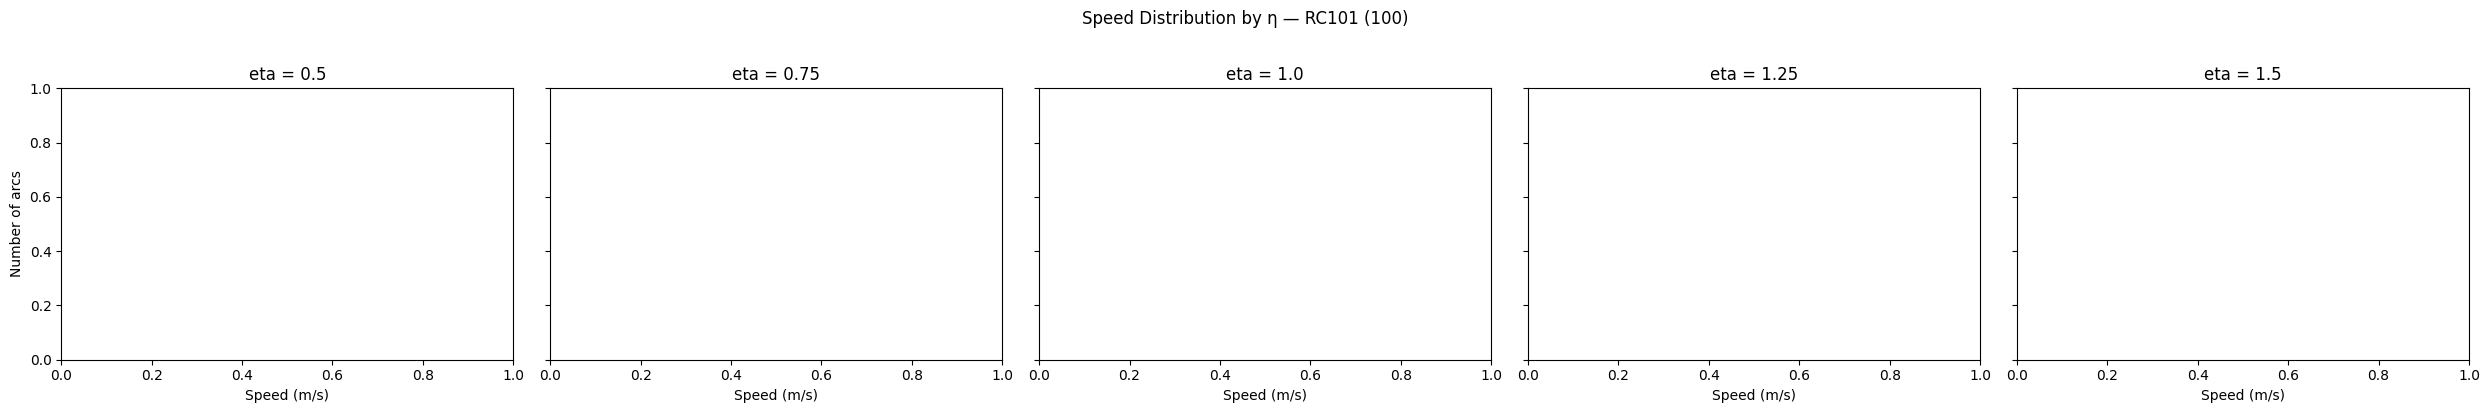

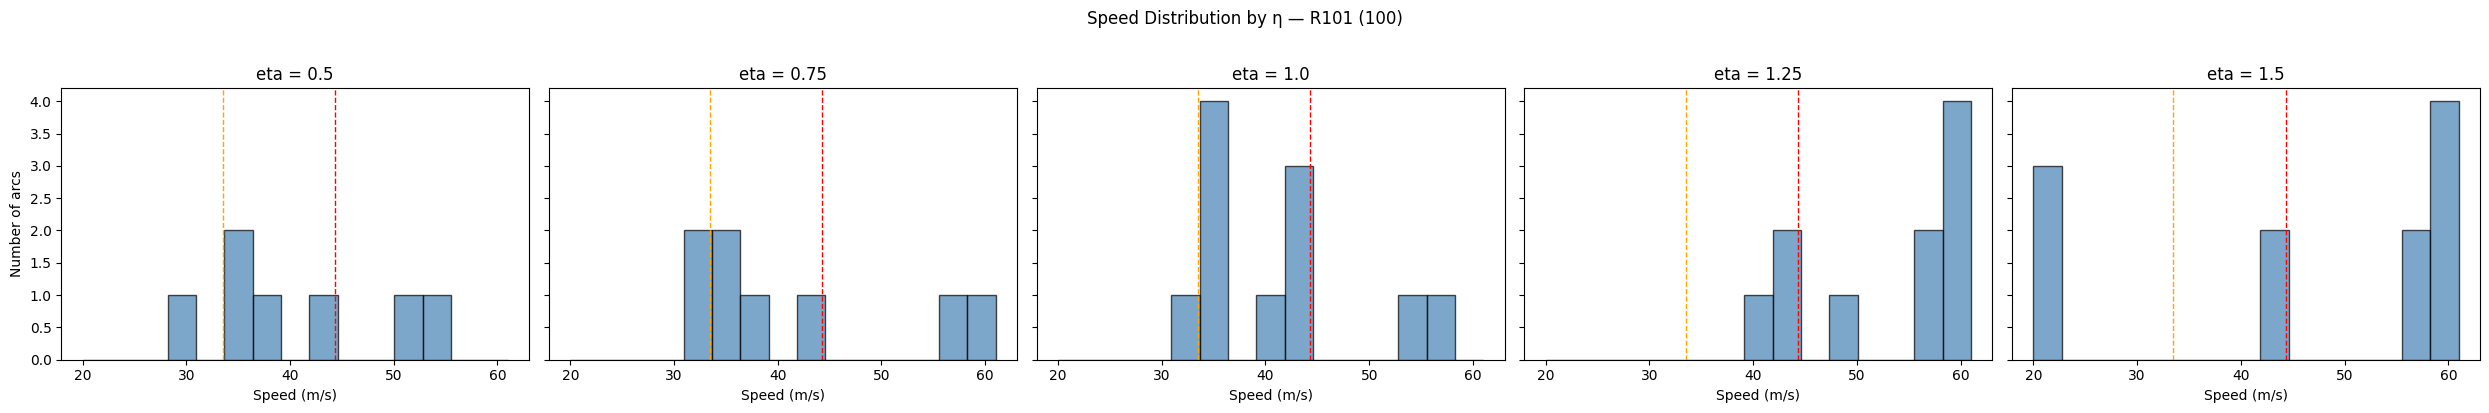

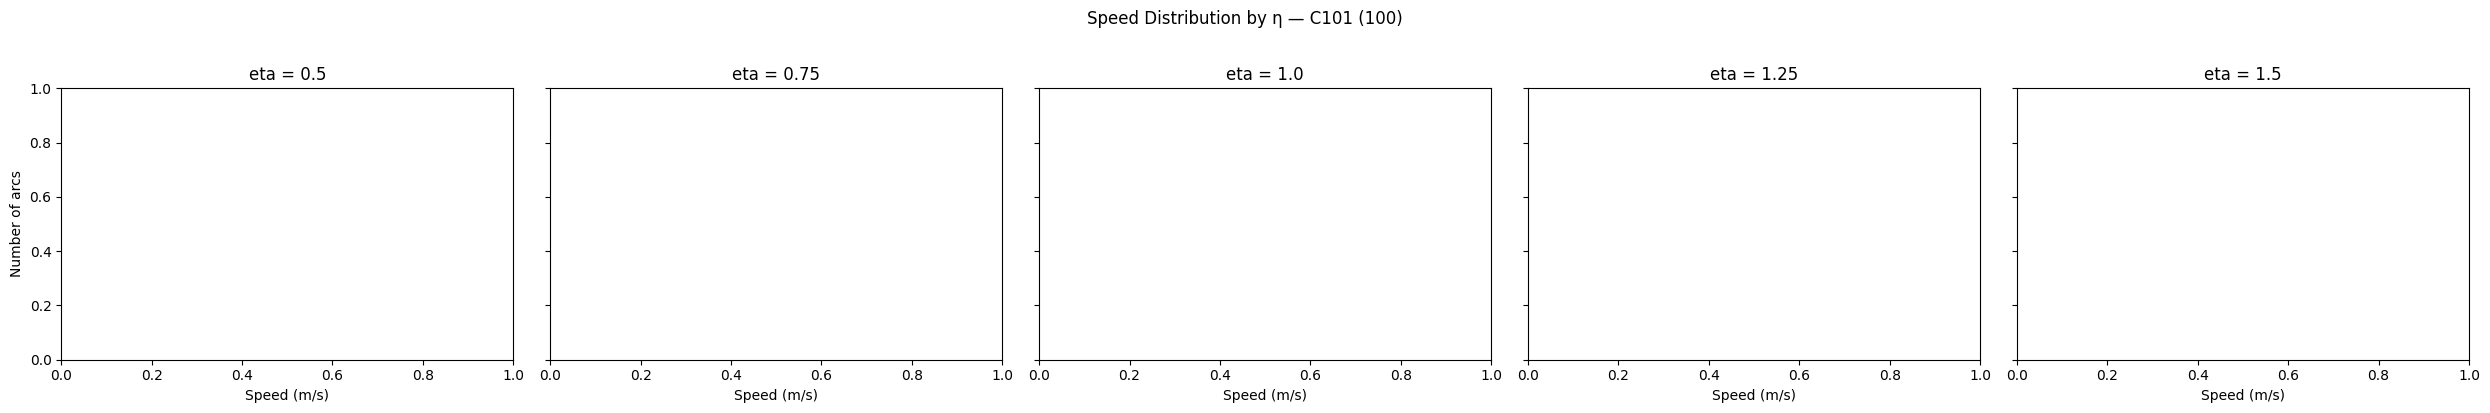

In [7]:
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        instance, _, _ = make_instance(path)
        fig = speed_histogram_by_eta(instance, env, seed=SEED,
                                      eta_values=(0.5, 0.75, 1.0, 1.25, 1.5),
                                      time_limit=TIME_LIMIT)
        fig.suptitle(f'Speed Distribution by η — {name}', y=1.02)
        #display(fig)

## Not: Yukarida bazi plotlarin bos olmasinin sebepi sonucun optimal olmamasi; infeasible olmasi ya da gap olmasi. Kod optimal cozum varsa cizim yapiyor. Duzeltip gap olunca da cizim yapmasini sagladim. Run time cok uzun oldugu icin tekrar calistirmiyorum su an icin.

# 7. Arrival Time Distribution by Slope

Where within time windows does the drone arrive?
- Negative slopes → cluster near 0 (early arrival to capture decaying info)
- Positive slopes → cluster near 1 (late arrival to capture growing info)
- Zero slopes → uniform (no timing preference)

Histogram of normalized arrival positions $(a_j - e_j) / (\ell_j - e_j)$ within time windows, grouped by slope regime on all datasets.

**Purpose:** Show that the solver exploits information dynamics to optimize arrival timing:
- **Negative slopes:** Arrivals cluster near 0.0 (early end of time window) — the drone arrives early to capture info before it decays.
- **Positive slopes:** Arrivals cluster near 1.0 (late end of time window) — the drone delays to maximize information growth.
- **Zero slopes:** Approximately uniform — arrival time is irrelevant, confirming that timing has no effect in the static case.


Tour details — C101 (50), slope=negative

--- Gurobi Solver Report ---
      Edge  Total Time (s)  Loiter Time (s)  Speed (m/s)  SOCP Energy (J)  Real Energy (J)  Energy %  Arrival Time (s)      Time Window     Slope
     0->20           87.38             0.00        44.31       1359362.54       1376363.54    0.8091             87.38    [87.4, 637.9] -1.351670
    20->32          183.50             0.00        47.18       3101748.73       3101807.07    1.8233            270.87   [270.9, 873.8] -2.967907
    32->42          323.30             0.00        29.16       4592504.29       4595777.16    2.7015            594.17  [594.2, 1301.9] -1.896678
    42->33          166.60             0.00        61.00       4371128.06       4375809.61    2.5722            760.78  [760.2, 1380.6] -2.660232
    33->25          715.92           538.58        45.43      11575784.49      11576196.42    6.8048           1476.70 [1476.7, 1957.3] -3.672340
    25->31          270.87             0.00        3

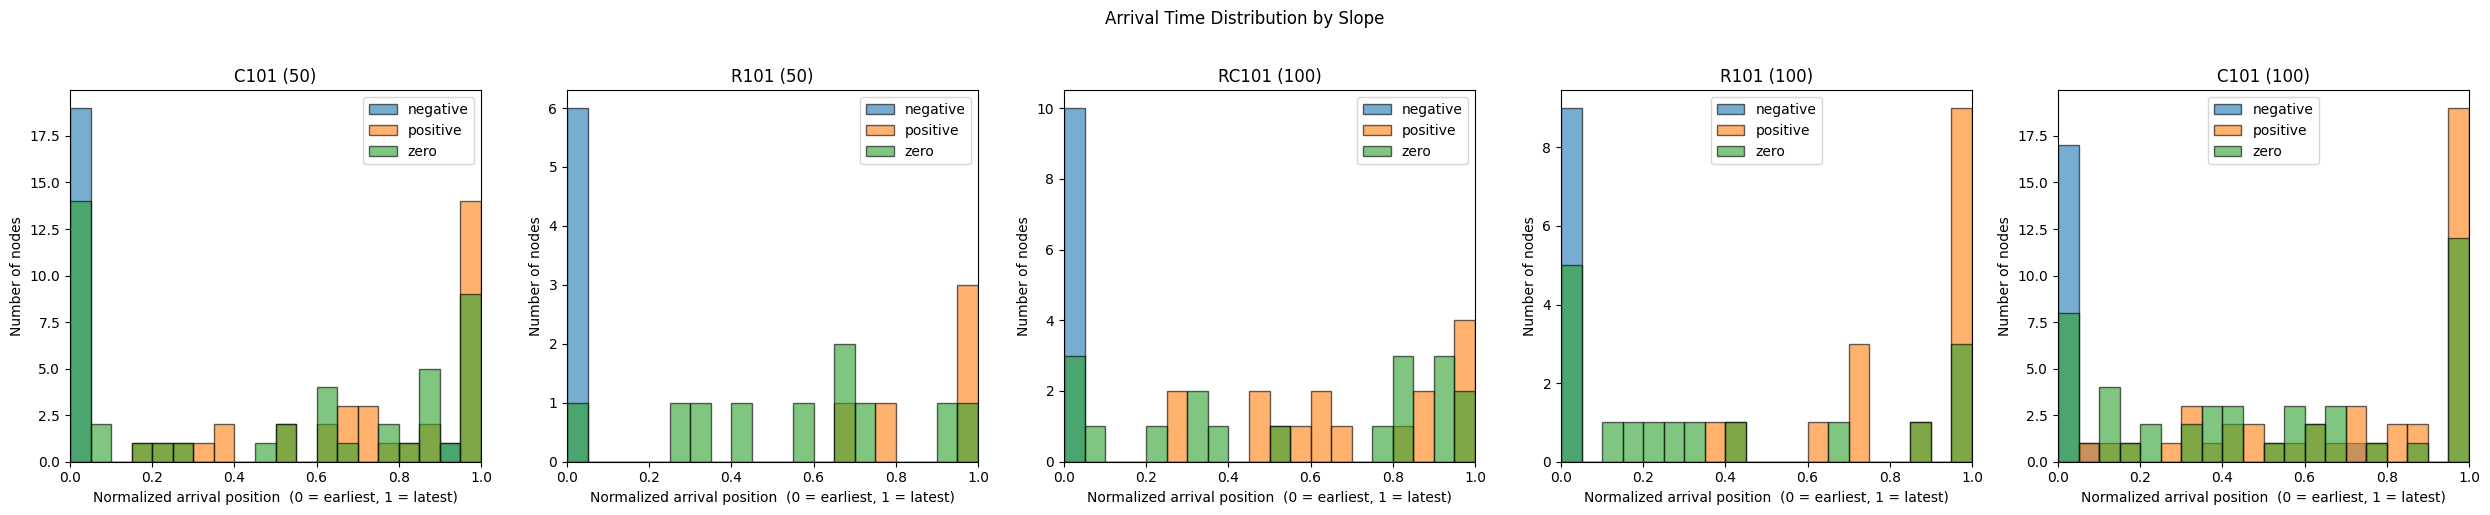

In [8]:
import matplotlib.pyplot as plt

n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(5 * n_datasets, 5), squeeze=False)
axes = axes[0]

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for idx, (name, path) in enumerate(datasets.items()):
        pairs = []
        for slope_type in ['negative', 'positive', 'zero']:
            inst, _, _ = make_instance(path, slope=slope_type)
            res = solve_model_gurobi(inst, seed=SEED, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False)
            if res:
                pairs.append((slope_type, res))
                print(f"\n{'='*60}")
                print(f"Tour details — {name}, slope={slope_type}")
                print_table(inst, res)

        arrival_time_histogram(inst, pairs, ax=axes[idx])
        axes[idx].set_title(f'{name}')

fig.suptitle('Arrival Time Distribution by Slope', y=1.02)
fig.tight_layout()

## 8. Single Run with Detailed Output

Detailed solver output and tour table for inspection.

**Purpose:** Sanity check and detailed inspection of a single solution. Verify that time windows are respected, energy budget is not exceeded, and the speed/arrival patterns match expectations from the aggregate experiments above.

In [9]:
instance, graph, uav = make_instance(datasets["R101 (50)"])

with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 1)
    env.start()
    res = solve_model_gurobi(instance, seed=SEED, time_limit=TIME_LIMIT,
                             env=env, prune=False, stats=True)
    print_table(instance, res)

Set parameter Username
Set parameter LicenseID to value 2761897
Academic license - for non-commercial use only - expires 2027-01-07
Set parameter Seed to value 42
Set parameter TimeLimit to value 600
Set parameter MIPFocus to value 1
Set parameter Threads to value 0
Set parameter Method to value 2
Set parameter ScaleFlag to value 2


Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (mac64[arm] - Darwin 23.6.0 23G93)

CPU model: Apple M3 Pro
Thread count: 11 physical cores, 11 logical processors, using up to 11 threads

Non-default parameters:
TimeLimit  600
Method  2
ScaleFlag  2
MIPFocus  1
Seed  42

Optimize a model with 20606 rows, 15402 columns and 61406 nonzeros (Max)
Model fingerprint: 0x8491cc0d
Model has 100 linear objective coefficients
Model has 7650 quadratic constraints
Variable types: 12801 continuous, 2601 integer (2601 binary)
Coefficient statistics:
  Matrix range     [2e-02, 3e+00]
  QMatrix range    [1e+00, 1e+00]
  Objective range  [1e+03, 1e+06]
  Bounds range     [1e+00, 3e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 11888 rows and 8912 columns
Presolve time: 0.59s
Presolved: 8718 rows, 6490 columns, 48054 nonzeros
Presolved model has 3198 quadratic constraint(s)
Variable types: 5378 continuous, 1112 integer (1112 binary)
Root barrier log...

Ordering time: 0.01s

Barrier statistics:

## 9. Solver Reproducibility

5 runs with different Gurobi seeds per dataset. Report mean/std of objective and time.

**Settings:** All 5 datasets, $\eta = 1$, random slopes, time limit = 600s.

**Purpose:** Verify that Gurobi's internal randomization does not produce large variance in solution quality. If the instance is solved to optimality, all seeds should give the same objective. If the time limit is hit, small variance is acceptable; large variance would indicate solver instability.

In [11]:
repro_rows = []
with gp.Env(empty=True) as env:
    env.setParam('OutputFlag', 0)
    env.start()

    for name, path in datasets.items():
        instance, _, _ = make_instance(path)
        print(f"\n{'='*60}")
        print(f"  {name}")
        for s in [42, 123, 456, 789, 1024]:
            res = solve_model_gurobi(instance, seed=s, time_limit=TIME_LIMIT,
                                     env=env, prune=False, stats=False)
            repro_rows.append({
                "Instance": name,
                "Seed": s,
                "Objective": round(res["obj"], 2) if res else None,
                "Time (s)": round(res["solve_time"], 2) if res else None,
                "Gap (%)": f"{res['gap']*100:.4f}" if res and res.get("gap") is not None else "-",
                "Tour nodes": len(res["tour"]) - 2 if res and res.get("tour") else 0,
            })

df_repro = pd.DataFrame(repro_rows)

# Summary per dataset
for name in datasets:
    sub = df_repro[df_repro['Instance'] == name]
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(sub.to_string(index=False))
    print(f"  Objective: mean={sub['Objective'].mean():.2f}, std={sub['Objective'].std():.2f}")
    print(f"  Time:      mean={sub['Time (s)'].mean():.2f}, std={sub['Time (s)'].std():.2f}")

df_repro


  C101 (50)

  R101 (50)

  RC101 (100)

  R101 (100)

  C101 (100)

  C101 (50)
 Instance  Seed  Objective  Time (s) Gap (%)  Tour nodes
C101 (50)    42    14669.2      8.24  0.0000          33
C101 (50)   123    14669.2      4.73  0.0000          33
C101 (50)   456    14669.2      6.26  0.0000          33
C101 (50)   789    14669.2      6.44  0.0000          33
C101 (50)  1024    14669.2      4.96  0.0000          33
  Objective: mean=14669.20, std=0.00
  Time:      mean=6.13, std=1.40

  R101 (50)
 Instance  Seed  Objective  Time (s) Gap (%)  Tour nodes
R101 (50)    42  144232.37      3.31  0.0000           6
R101 (50)   123  144232.37     13.60  0.0000           6
R101 (50)   456  144232.37      1.38  0.0000           6
R101 (50)   789  144232.37      1.18  0.0000           6
R101 (50)  1024  144232.37      9.79  0.0000           6
  Objective: mean=144232.37, std=0.00
  Time:      mean=5.85, std=5.56

  RC101 (100)
   Instance  Seed  Objective  Time (s) Gap (%)  Tour nodes
RC101 

,Instance,Seed,Objective,Time (s),Gap (%),Tour nodes
0,C101 (50),42,14669.20,8.24,0.0000,33
1,C101 (50),123,14669.20,4.73,0.0000,33
2,C101 (50),456,14669.20,6.26,0.0000,33
3,C101 (50),789,14669.20,6.44,0.0000,33
4,C101 (50),1024,14669.20,4.96,0.0000,33
5,R101 (50),42,144232.37,3.31,0.0000,6
6,R101 (50),123,144232.37,13.60,0.0000,6
7,R101 (50),456,144232.37,1.38,0.0000,6
8,R101 (50),789,144232.37,1.18,0.0000,6
9,R101 (50),1024,144232.37,9.79,0.0000,6
